# Three-Dimensional Heat Equation

In [1]:
import os
import jax
import jax.numpy as jnp
from flax import linen as nn
from flax.training import train_state
import optax
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
from functools import partial
import scipy.io
from sklearn.model_selection import train_test_split
import time
import pickle
import random

from scipy.stats import pearsonr
import matplotlib.ticker as mticker

## DeepONet Class and RK4 Time-stepping

In [2]:
class BranchNet(nn.Module):
    features: list

    @nn.compact
    def __call__(self, x):
        init = nn.initializers.glorot_normal()
        
        # #x has shape (ns, nx, ny) - so add channel dimension: (ns, nx, ny, nc)
        x = x[..., jnp.newaxis]

        #2D Convolutional layers and pooling layers
        x = nn.Conv(features = 32, kernel_size = (3,3,3), strides = (2,2,1), padding = "SAME")(x)
        x = nn.relu(x)
        x = nn.max_pool(x, window_shape=(2,2,2), strides = (2,2,2), padding = "SAME")

        x = nn.Conv(features = 32, kernel_size = (2,2,2), strides = (2,2,1), padding = "SAME")(x)
        x = nn.relu(x)
        x = nn.avg_pool(x, window_shape = (2,2,2), strides = (2,2,2), padding = "SAME")

        x = x.flatten()   #flattening layer
        for feat in self.features[:-1]:
            x = nn.Dense(feat,kernel_init = init)(x)
            x = nn.tanh(x)
        x = nn.Dense(self.features[-1])(x)
        return x

class TrunkNet(nn.Module):
    features: list

    @nn.compact
    def __call__(self, x):
        init = nn.initializers.glorot_normal()
        for feat in self.features:
            x = nn.Dense(feat,kernel_init = init)(x)
            x = nn.tanh(x)
        return x

class DeepONet(nn.Module):
    branch_features: list
    trunk_features: list
    
    def setup(self):
        self.branch_net = BranchNet(self.branch_features)
        self.trunk_net = TrunkNet(self.trunk_features)

    @nn.compact
    def __call__(self, branch_input, trunk_input):
        branch_out = jax.vmap(self.branch_net, in_axes = 0)(branch_input) 
        trunk_out = jax.vmap(self.trunk_net, in_axes = 0)(trunk_input)     
        output = jnp.einsum('bi,ti->bt', branch_out, trunk_out) 
        bias = self.param('bias', nn.initializers.zeros, (1,))
        output = output + bias
        return output

In [3]:
@jax.jit
def RK4(params,branch_x,trunk_x,dt = 0.01):
    
    curr_state = branch_x
    k1 = model_jit(params,curr_state,trunk_x)
    k1 = k1.reshape(k1.shape[0],nx,ny,nz)
    k2 = model_jit(params,curr_state+0.5*dt*k1,trunk_x)
    k2 = k2.reshape(k2.shape[0],nx,ny,nz)
    k3 = model_jit(params,curr_state+0.5*dt*k2,trunk_x)
    k3 = k3.reshape(k3.shape[0],nx,ny,nz)
    k4 = model_jit(params,curr_state+dt*k3,trunk_x)
    k4 = k4.reshape(k4.shape[0],nx,ny,nz)
    next_state = curr_state+(dt/6)*(k1+2*k2+2*k3+k4)
    next_state = next_state.reshape(next_state.shape[0],nx*ny*nz)
    return next_state

In [4]:
p = 100
branch_features = [256,128]+[p]
trunk_features = [128]*4+[p]
model = DeepONet(branch_features=branch_features, trunk_features=trunk_features)
model_jit = jax.jit(model.apply)
key = jax.random.PRNGKey(0)

## Data Preparation

In [ ]:
dataset = np.load('/home/dnayak2/scr4_sgoswam4/Dibya/backup/Datasets/3D_Heat_Conduction/processed/3d_heat_field_results.npz')
outputs = dataset['heat_field'] 
outputs = jnp.array(outputs)
del dataset
nsamples = outputs.shape[0]
nx = outputs.shape[2]
ny = outputs.shape[3]
nz = outputs.shape[4]
nt = outputs.shape[1]
param_path = "ti_don_3d_heat.pkl" 

xspan = jnp.linspace(0, 1, nx)
yspan = jnp.linspace(0, 1, ny)
zspan = jnp.linspace(0, 1, nz)
[x,y,z] = jnp.meshgrid(xspan, yspan,zspan, indexing = 'ij')
grid = jnp.transpose(jnp.array([x.flatten(), y.flatten(),z.flatten()]))
x = np.linspace(0,1,nx)
y = np.linspace(0,1,ny)
z = np.linspace(0,1,nz)
t = np.linspace(0,1,nt)

data_test = outputs
del outputs

with open(param_path, "rb") as f:
    params = pickle.load(f)
    


In [6]:
folder = "/home/rroy13/jax.venv/DeepONet/Coupling3D/3D_Heat"
os.makedirs(folder, exist_ok=True)

## Residual and Error Estimator

In [ ]:
## EMA-based error Estimator
@jax.jit
def heat3d_res_error(params,u_curr, x,y,z, grid,eta_hist, K = 1.0): # u_curr -> branch input, #coll_points -> trunk input
    
    # print(u_curr.shape)
    x = x*nx
    y = y*ny
    z = z*nz*2
    u_curr_t = model.apply(params,u_curr, grid) 
    # print(u_curr_t.shape)
    u_curr_t = u_curr_t[0].reshape(nx,ny,nz)
    u_curr = u_curr[0]
    #print(u_curr_t.shape)
    u = u_curr
    u_t = u_curr_t
    u_x = jnp.gradient(u,x,axis = 0)
    u_y = jnp.gradient(u,y,axis = 1)
    u_z = jnp.gradient(u,z,axis = 2)

    u_xx = jnp.gradient(u_x,x,axis = 0)
    u_yy = jnp.gradient(u_y,y,axis = 1)
    u_zz = jnp.gradient(u_z,z,axis = 2)

    #max_u = max(u)
    res = u_t - K*(u_xx+u_yy+u_zz)
    #rmax = max(res)
    alpha = 0.01
    r = jnp.linalg.norm(res)/jnp.linalg.norm(u_curr)
    eta = alpha*r+(1-alpha)*eta_hist
    
    return res,eta

## Numerical Solver

In [ ]:
def create_l_shaped_domain(nx, ny, nz):
    
    # Create full box
    domain = np.ones((nx, ny, nz), dtype=bool)
    
    # Remove upper-right corner to create L-shape
    # Remove the region where x >= nx//2 and y >= ny//2
    cut_x = nx // 2
    cut_y = ny // 2
    domain[cut_x:, cut_y:, :] = False
    
    # Identify boundary nodes (external boundaries AND internal cut edges)
    boundary = np.zeros((nx, ny, nz), dtype=bool)
    
    for i in range(nx):
        for j in range(ny):
            for k in range(nz):
                if domain[i, j, k]:
                    # Check if on the external edge of the grid
                    if i == 0 or j == 0 or k == 0 or k == nz-1:
                        boundary[i, j, k] = True
                    # Check if on the outer edges (not the cut edges)
                    elif (i == nx-1 and j < cut_y) or (j == ny-1 and i < cut_x):
                        boundary[i, j, k] = True
                    # Check if adjacent to removed region (internal boundary)
                    elif (i+1 < nx and not domain[i+1, j, k]) or \
                         (j+1 < ny and not domain[i, j+1, k]):
                        boundary[i, j, k] = True
    
    # Interior nodes are domain nodes that are not boundary nodes
    interior = domain & (~boundary)
    
    return domain, boundary, interior

def apply_boundary_conditions(u, boundary, bc_value=0.0):
    
    # Apply fixed Dirichlet boundary condition
    u[boundary] = bc_value
    
    return u

def solve_heat_equation(u0, domain, boundary, dt=0.01, nt=100, alpha=1.0,
                       bc_value=0.0):
    
    nx, ny, nz = u0.shape
    dx = dy = dz = 1.0  # Grid spacing
    
    # Stability check
    stability = alpha * dt * (1/dx**2 + 1/dy**2 + 1/dz**2)
    if stability > 1/2:
        print(f"Warning: Stability criterion violated! {stability:.4f} > {1/2:.4f}")
    
    # Initialize solution array
    solution = np.zeros((nt+1, nx, ny, nz))
    solution[0] = u0.copy()
    
    # Fix boundary conditions at t=0
    solution[0][boundary] = bc_value
    
    u = solution[0].copy()
    
    # Enforce Dirichlet BC at t=0 for correctness
    u[~domain] = bc_value
    u[boundary] = bc_value
    
    u_new = np.zeros_like(u)
    
    for n in range(nt):
        u_new[:] = u
        
        # Update interior points using explicit finite difference
        for i in range(1, nx-1):
            for j in range(1, ny-1):
                for k in range(1, nz-1):
                    if domain[i, j, k] and not boundary[i, j, k]:
                        # Laplacian using central differences
                        laplacian = (
                            (u[i+1, j, k] - 2*u[i, j, k] + u[i-1, j, k]) / dx**2 +
                            (u[i, j+1, k] - 2*u[i, j, k] + u[i, j-1, k]) / dy**2 +
                            (u[i, j, k+1] - 2*u[i, j, k] + u[i, j, k-1]) / dz**2
                        )
                        u_new[i, j, k] = u[i, j, k] + alpha * dt * laplacian
        
        # Apply boundary conditions - enforce fixed Dirichlet at boundaries
        u_new[boundary] = bc_value
        
        # Enforce regions outside the domain to have fixed temperature at `bc_value`
        u_new[~domain] = bc_value

        interior_mask = domain & (~boundary)
       
        # Update solution for next time step
        u[:] = u_new
        solution[n+1] = u.copy()
        
        # Explicitly re-enforce fixed boundary conditions in solution
        solution[n+1][boundary] = bc_value
        
    # Clear memory for large arrays
    del u, u_new
    # gc.collect()
    
    return solution


## Numerical Experimentation

### Correlation between EMA-based estimator and actual error

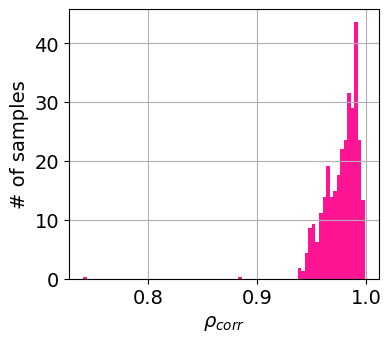

In [ ]:
## All Samples to compute pearson's coefficient
np.random.seed(80)
test_sample = np.random.choice(1000, size=1000, replace=False)
u_pred_model = np.zeros((len(test_sample),nt,nx,ny,nz))
eta_list_final = np.zeros((len(test_sample),nt-1))
l2error_list_final = np.zeros((len(test_sample),nt))
for k,ns in enumerate(test_sample):
    u_test = data_test[ns,:nt][None, ...]
    branch_test = data_test[ns,0][None, ...]
    trunk_test = grid
    u_pred_model[k,0,:,:,:] = branch_test
    u_curr = branch_test
    eta = 0
    eta_list = []
    for i in range(1, nt):
        u_curr = RK4(params,u_curr,grid,dt = 0.01)
        u_curr = u_curr.reshape(-1,nx,ny,nz)
        u_curr = u_curr.at[:,nx//2:,ny//2:,:].set(0.0)
        res,eta = heat3d_res_error(params,u_curr,x,y,z,grid,eta)
        eta_list.append(eta)
        u_pred_model[k,i,:,:,:] = u_curr
        
    eta_list_final[k]=np.array(eta_list)
    l2_error = []
    for i in range(nt):
        l2_error.append(np.linalg.norm(u_pred_model[k,i] - u_test[0,i])/\
                         np.linalg.norm(u_test[0,i]))
   
    l2error_list_final[k] = np.array(l2_error)

r_list = [pearsonr(np.array(l2error_list_final[i,1:]),
                   np.array(eta_list_final[i]))[0] for i in range(len(test_sample))]
r_list = np.array(r_list)

plt.figure(figsize = (4,3.5))
plt.hist(r_list,density = True,bins = 80,color = 'deeppink')
# plt.title("Correlation between error estimator and actual error",fontsize = 14)
plt.xlabel(rf"$\rho_{{corr}}$",fontsize = 14)
plt.ylabel("# of samples",fontsize = 14)
plt.grid()
ax = plt.gca()
ax.xaxis.set_major_locator(mticker.MultipleLocator(0.1))
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)

plt.savefig(folder+"/pearson_coeff.pdf",dpi = 300, bbox_inches='tight')
plt.show()

In [ ]:
## Autoregressive Predictions
u_auto = np.load('u_pred_auto_3dheat.npz')['arr_0']

### Sample-by-sample study between AR-DON, TI-DON and ANCHOR (Ours)

In [155]:
# Visualize the sample
np.random.seed(100)
# test_sample = random.sample(range(0, 2500), 1)
test_sample = np.random.choice(1000, size=1, replace=False)

print(f"Sample chosen: {test_sample}")
u_pred_auto = u_auto[test_sample] 
folder = "/home/rroy13/jax.venv/DeepONet/Coupling3D/3D_Heat"
sample_folder = f"/sample_{test_sample[0]}"
os.makedirs(folder+sample_folder, exist_ok=True)

u_test = data_test[test_sample,:nt,:,:]
branch_test = data_test[test_sample,0,:,:]
trunk_test = grid


Sample chosen: [249]


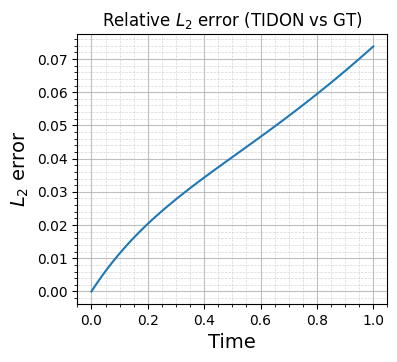

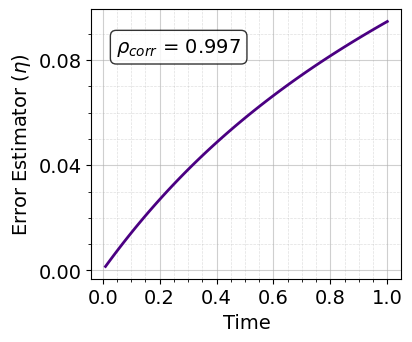

In [ ]:
u_pred_model = np.zeros((nt,nx,ny,nz))
u_pred_model[0,:,:,:] = branch_test
u_curr = branch_test
eta = 0
eta_list = []

for i in range(1, nt):
    u_curr = RK4(params,u_curr,grid)
    u_curr = u_curr.reshape(-1,nx,ny,nz)
    u_curr = u_curr.at[:,nx//2:,ny//2:,:].set(0.0)
    res,eta = heat3d_res_error(params,u_curr,x,y,z,grid,eta)
    eta_list.append(eta)
    u_pred_model[i,:,:] = u_curr

l2_error1 = []
for i in range(nt):
    l2_error1.append(np.linalg.norm(u_pred_model[i,:,:] - u_test[0,i,:,:])/np.linalg.norm(u_test[0,i,:,:]))

plt.figure(figsize =(4,3.5))
plt.plot(t,jnp.array(l2_error1),label = 'TIDON')

plt.title(f"Relative $L_2$ error (TIDON vs GT)")
plt.xlabel("Time",fontsize = 14)
plt.ylabel("$L_2$ error",fontsize = 14)
plt.grid(which='major', linestyle='-', axis = 'both', linewidth=0.8, alpha=0.8)
plt.grid(which='minor', linestyle='--',axis = 'both', linewidth=0.5, alpha=0.5)
plt.minorticks_on()

# plt.savefig(folder+sample_folder+"/err_estm_l2_error.png",dpi=300)
plt.show()

plt.figure(figsize =(4,3.5))
plt.plot(t[1:],np.array(eta_list),color = 'indigo',lw = 2)
# plt.title(f"EMA-based Error Estimator")#, Sample:{test_sample[0]}")
plt.xlabel("Time",fontsize = 14)
plt.ylabel(r"Error Estimator ($\eta$)",fontsize = 14)
plt.grid(which='major', linestyle='-', axis = 'both', linewidth=0.8, alpha=0.6)
plt.grid(which='minor', linestyle='--',axis = 'both', linewidth=0.5, alpha=0.4)
plt.text(0.08, 0.9, rf"$\rho_{{corr}}$ = {pearsonr(np.array(l2_error1[1:]),np.array(eta_list))[0]:.3f}",
    transform=plt.gca().transAxes,fontsize = 14,va='top',
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor="black",
        alpha=0.8))
plt.minorticks_on()
ax = plt.gca()
ax.xaxis.set_major_locator(mticker.MultipleLocator(0.2))
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.04))
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)

plt.savefig(folder+sample_folder+"/err_estm.pdf",dpi = 300, bbox_inches='tight')
plt.show()

In [ ]:
# Timing TI-DON
u_curr = branch_test
st = time.time()
for i in range(1, nt):
    u_curr = RK4(params,u_curr,grid)
    u_curr = u_curr.reshape(-1,nx,ny,nz)
    u_curr = u_curr.at[:,nx//2:,ny//2:,:].set(0.0)
    u_pred_model[i,:,:] = u_curr
et = time.time()-st
print("TIDON Time: ",et)


TIDON Time:  0.17378020286560059


In [ ]:
## Timing Numerical Solver
domain, boundary, interior = create_l_shaped_domain(nx, ny, nz)
boundary_temp = 0.0
alpha = 1.0
st = time.time()
u_solver = solve_heat_equation(branch_test[0], domain, boundary, dt=0.01, nt=101, 
                                      alpha=alpha, bc_value=boundary_temp)
et = time.time()-st
print("Solver Time: ", et) 

Solver Time:  2.6129374504089355


In [ ]:
## ANCHOR Framework
nt = 101
mark_model = []
mark_coup = []
domain, boundary, interior = create_l_shaped_domain(nx, ny, nz)
boundary_temp = 0.0
alpha = 1.0

u_pred_coup= np.zeros((nt,nx,ny,nz))
u_pred_coup[0,:,:,:] = branch_test
i = 1
u_curr = RK4(params,branch_test,trunk_test) #u_curr at i=1
u_curr = u_curr.reshape(-1,nx,ny,nz)
u_curr = u_curr.at[:,nx//2:,ny//2:,:].set(0.0)

mark_model.append(i)

eta_thres = 0

res,eta = heat3d_res_error(params,branch_test,x,y,z,grid,eta_hist=0)
rnorm0 = np.linalg.norm(res)
print(np.exp(-rnorm0))
umax0 = np.max(branch_test)
print(umax0)
st = time.time()
while i<nt:
    ti = t[i]
    res,eta = heat3d_res_error(params,u_curr,x,y,z,grid,eta) # computes residual at ith step using u_curr at ith step
    Kut = np.exp(-3*ti)*np.exp(-umax0)*umax0
    eta_thres = (Kut)
    print(f"estimator:{eta:.6f}|threshold:{eta_thres:.6f}")
    
    if eta<eta_thres:
        #print(i)
        #print(f"tidon {i}")
        u_pred_coup[i,:,:,:] = u_curr
        i+=1
        u_curr = RK4(params,u_curr,trunk_test)  # u_curr at i+1
        u_curr = u_curr.reshape(-1,nx,ny,nz)
        u_curr = u_curr.at[:,nx//2:,ny//2:,:].set(0.0)
        mark_model.append(i)
    else:
        print(f"ns {i}")
        u_init = u_curr[0]
        #u_init = u_pred_coup[i,:]
        dt = 0.01
        nsteps = 16

        u_final = solve_heat_equation(u_init, domain, boundary, dt=dt, nt=nsteps-1, 
                                      alpha=alpha, bc_value=boundary_temp)
        
        # print('init',u0[1][1])
        # print('solution',u_final[0][1][1])
        if i+nsteps<nt:
            u_pred_coup[i:i+nsteps,:,:,:] = u_final
        else:
            nsteps = nt-i
            u_pred_coup[i:i+nsteps,:,:,:] = u_final[:nsteps,:,:,:]
        # print('u_pred_coup',u_pred_coup[i][1][1])
        mark_coup.append(list(range(i, i+nsteps)))
        i+=nsteps
        u_curr = u_pred_coup[i-1:i,:,:]#.reshape(1,dim_x)
        res,eta = heat3d_res_error(params,u_curr,x,y,z,grid,eta_hist=0)
        u_curr = RK4(params,u_curr,trunk_test)
        u_curr = u_curr.reshape(-1,nx,ny,nz)
        u_curr = u_curr.at[:,nx//2:,ny//2:,:].set(0.0)

et = time.time()
print("ANCHOR Time:",et-st)    

0.3759325
0.35684836
estimator:0.002978|threshold:0.242369
estimator:0.004442|threshold:0.235206
estimator:0.005890|threshold:0.228255
estimator:0.007320|threshold:0.221509
estimator:0.008735|threshold:0.214962
estimator:0.010133|threshold:0.208609
estimator:0.011516|threshold:0.202444
estimator:0.012882|threshold:0.196461
estimator:0.014234|threshold:0.190654
estimator:0.015570|threshold:0.185020
estimator:0.016891|threshold:0.179552
estimator:0.018197|threshold:0.174245
estimator:0.019489|threshold:0.169095
estimator:0.020768|threshold:0.164098
estimator:0.022031|threshold:0.159248
estimator:0.023282|threshold:0.154541
estimator:0.024518|threshold:0.149974
estimator:0.025741|threshold:0.145542
estimator:0.026951|threshold:0.141240
estimator:0.028148|threshold:0.137066
estimator:0.029332|threshold:0.133015
estimator:0.030504|threshold:0.129084
estimator:0.031663|threshold:0.125269
estimator:0.032810|threshold:0.121567
estimator:0.033945|threshold:0.117974
estimator:0.035068|threshold:

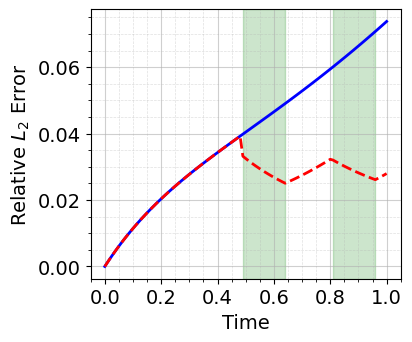

In [ ]:
ts1 = [m[0] * 0.01 for m in mark_coup]
ts2 = [m[-1] * 0.01 for m in mark_coup]

# Plot of L2 error for each time step
l2_error1 = []
l2_error2 = []
for i in range(nt):
    l2_error1.append(np.linalg.norm(u_pred_model[i] - u_test[:,i])/np.linalg.norm(u_test[:,i]))
    l2_error2.append(np.linalg.norm(u_pred_coup[i] - u_test[:, i])/np.linalg.norm(u_test[:,i]))

plt.figure(figsize=(4,3.5))
plt.plot(t,np.array(l2_error1),color = 'b',label = 'TI-DON',lw = 2)
plt.plot(t,np.array(l2_error2),color = 'r',linestyle = '--',label = 'ANCHOR',lw = 2)
for x1,x2 in zip(np.array(ts1),np.array(ts2)):
    plt.axvspan(x1,x2,color = 'g',alpha = 0.2)
plt.xlabel("Time",fontsize = 14)
plt.ylabel(r"Relative $L_2$ Error",fontsize = 14)
# plt.title(f"Relative $L_2$ Error")
plt.grid(which='major', linestyle='-', axis = 'both', linewidth=0.8, alpha=0.6)
plt.grid(which='minor', linestyle='--',axis = 'both', linewidth=0.5, alpha=0.4)
plt.minorticks_on()
ax = plt.gca()
ax.xaxis.set_major_locator(mticker.MultipleLocator(0.2))
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
# plt.legend()
plt.savefig(folder+sample_folder+"/coupled_L2_error.pdf",dpi = 300, bbox_inches='tight')
plt.show()


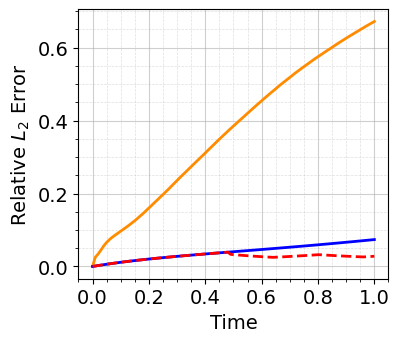

In [ ]:
l2_error1 = []
l2_error2 = []
l2_error3 = []
for i in range(nt):
    l2_error1.append(np.linalg.norm(u_pred_model[i] - u_test[:,i])/np.linalg.norm(u_test[:,i]))
    l2_error2.append(np.linalg.norm(u_pred_coup[i] - u_test[:, i])/np.linalg.norm(u_test[:,i]))
    l2_error3.append(np.linalg.norm(u_pred_auto[:,i] - u_test[:, i])/np.linalg.norm(u_test[:,i]))

plt.figure(figsize=(4,3.5))
plt.plot(t,np.array(l2_error3),color = 'darkorange',label = 'AR-DON',lw = 2)
plt.plot(t,np.array(l2_error1),color = 'b',label = 'TI-DON',lw = 2)
plt.plot(t,np.array(l2_error2),color = 'r', linestyle = '--',label = 'ANCHOR',lw = 2)
plt.xlabel("Time",fontsize = 14)
plt.ylabel(r"Relative $L_2$ Error",fontsize = 14)
# plt.title(f"Relative $L_2$ Error")
plt.grid(which='major', linestyle='-', axis = 'both', linewidth=0.8, alpha=0.6)
plt.grid(which='minor', linestyle='--',axis = 'both', linewidth=0.5, alpha=0.4)
plt.minorticks_on()
# plt.legend()
ax = plt.gca()
ax.xaxis.set_major_locator(mticker.MultipleLocator(0.2))
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
plt.savefig(folder+sample_folder+"/l2errors.pdf",dpi = 300, bbox_inches='tight')
plt.show()

0.34375 0.3125 0.3125


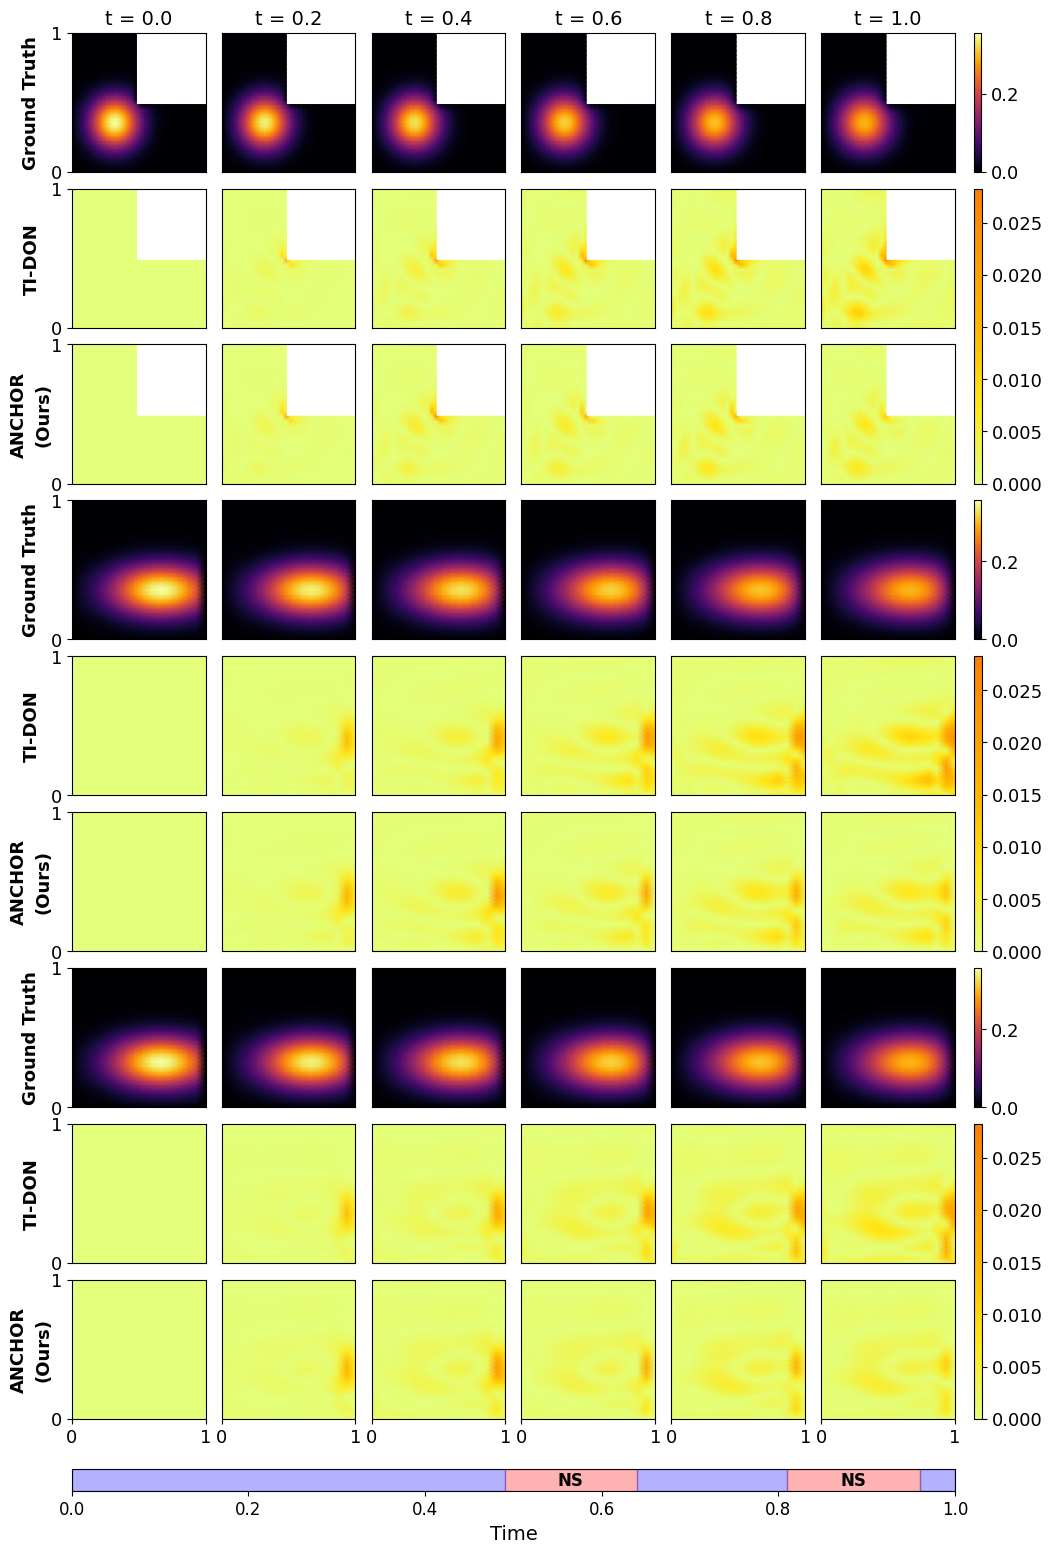

In [ ]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# GRID
x = np.linspace(0, 1, nx)
y = np.linspace(0, 1, ny)
z = np.linspace(0, 1, nz)

tsteps = [0, 20, 40, 60, 80, 100]
nrow = 3
ncol = len(tsteps)

row_labels = [
    "Ground Truth",
    # "Autoregressive",
    "TI-DON",
    "ANCHOR\n(Ours)",
]

# SLICE LOCATIONS
x_max = jnp.argmax(jnp.max(np.array(u_test[0]), axis=(0,2,3)))
y_max = jnp.argmax(jnp.max(np.array(u_test[0]), axis=(0,1,3)))
z_max = jnp.argmax(jnp.max(np.array(u_test[0]), axis=(0,1,2)))
print(x_max/32,y_max/32,z_max/32)

# COLOR LIMITS PER ROW
row_clims = {}
row_clims[0] = (min(u_test[0][t].min() for t in tsteps),
                max(u_test[0][t].max() for t in tsteps))

# row_clims[1] = (min(np.abs(u_pred_auto[0][t] - u_test[0][t]).min() for t in tsteps),
#                 max(np.abs(u_pred_auto[0][t] - u_test[0][t]).max() for t in tsteps))

row_clims[1] = (min(np.abs(u_pred_model[t] - u_test[0][t]).min() for t in tsteps),
                max(np.abs(u_pred_model[t] - u_test[0][t]).max() for t in tsteps))

row_clims[2] = (min(np.abs(u_pred_coup[t] - u_test[0][t]).min() for t in tsteps),
                max(np.abs(u_pred_coup[t] - u_test[0][t]).max() for t in tsteps))


# FIGURE
total_rows = 3 * nrow  # 3 planes
fig = plt.figure(figsize=(12, 18))

# Create GridSpec
gs = gridspec.GridSpec(total_rows, ncol, hspace=0.12, wspace=0.12)

top_row_axes = []

def plot_plane(plane_id, xlabel, ylabel):
    err_axes = []          # axes for i = 1 and 2 (this plane only)
    err_mappable = None
    for i in range(nrow):
        row_axes = []
        im = None

        for j in range(ncol):
        
            # SELECT GRID CELL
            row_idx = plane_id * nrow + i
            ax = fig.add_subplot(gs[row_idx, j])

            vmin, vmax = row_clims[i]

            # SELECT SLICE
            if plane_id == 0:          # XY
                gt = u_test[0][tsteps[j]][:,:,z_max]
                mask = domain[:,:,z_max]
                xx, yy = x, y

            elif plane_id == 1:        # YZ
                gt = u_test[0][tsteps[j]][:,y_max,:]
                mask = domain[:,y_max,:]
                xx, yy = z, x

            else:                      # ZX
                gt = u_test[0][tsteps[j]][x_max,:,:]
                mask = domain[x_max,:,:]
                xx, yy = z, y


            # DATA PER ROW
            if i == 0:
                data = gt
            # elif i == 1:
            #     if plane_id == 0:
            #         data = np.abs(u_pred_auto[0][tsteps[j]][:,:,z_max] - gt)
            #     elif plane_id == 1:
            #         data = np.abs(u_pred_auto[0][tsteps[j]][:,y_max,:] - gt)
            #     else:
            #         data = np.abs(u_pred_auto[0][tsteps[j]][x_max,:,:] - gt)
            elif i == 1:
                if plane_id == 0:
                    data = np.abs(u_pred_model[tsteps[j]][:,:,z_max] - gt)
                elif plane_id == 1:
                    data = np.abs(u_pred_model[tsteps[j]][:,y_max,:] - gt)
                else:
                    data = np.abs(u_pred_model[tsteps[j]][x_max,:,:] - gt)
            elif i == 2:
                if plane_id == 0:
                    data = np.abs(u_pred_coup[tsteps[j]][:,:,z_max] - gt)
                elif plane_id == 1:
                    data = np.abs(u_pred_coup[tsteps[j]][:,y_max,:] - gt)
                else:
                    data = np.abs(u_pred_coup[tsteps[j]][x_max,:,:] - gt)


            # MASK + PLOT
            data = np.ma.array(data, mask=~mask)

            im = ax.pcolormesh(
                xx, yy, data,
                cmap='inferno' if i == 0 else 'Wistia',
                shading='gouraud',
                vmin=vmin, vmax=vmax
            )
            # ax.set_aspect('equal')

            # TICKS
            # X-ticks only for last row
            if i == nrow - 1 and plane_id == 2:
                ax.tick_params(labelbottom=True)
                top_row_axes.append(ax)
                # ax.set_xlabel(xlabel, fontsize=12)
                
            else:
                ax.tick_params(bottom=False, labelbottom=False)

            # Y-ticks only for first column
            if j == 0:
                ax.tick_params(labelleft=True)
                # ax.set_ylabel(ylabel, fontsize=12)
                # Row label
                ax.text(
                    -0.3, 0.5, f"{row_labels[i]}",
                    transform=ax.transAxes,
                    rotation=90,
                    va='center', ha='center',
                    fontsize=13, fontweight='bold',
                    linespacing=1.5   # ← controls spacing between lines
                )
            else:
                ax.tick_params(left=False, labelleft=False)

            # Column titles (first row only)
            if i == 0 and plane_id == 0:
                ax.set_title(f"t = {0.01 * tsteps[j]}", fontsize=14)

            ax.tick_params(labelsize=13)
            ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
            ax.yaxis.set_major_locator(mticker.MultipleLocator(1))
               
            row_axes.append(ax)

        if i == 0:
            # Ground-truth colorbar (per plane)
            cbar = fig.colorbar(
                im, ax=row_axes,
                location='right',
                pad=0.02, fraction=0.03
            )
            cbar.ax.tick_params(labelsize=13)

        else:
            # Collect axes for shared error colorbar (rows i=1,2)
            err_axes.extend(row_axes)

            if err_mappable is None:
                err_mappable = im

    # SHARED ERROR COLORBAR FOR THIS PLANE (i = 1 & 2)
    cbar_err = fig.colorbar(
        err_mappable,
        ax=err_axes,
        location='right',
        pad=0.02,
        fraction=0.03,   # ↓↓↓ narrower bar
        aspect=35
        )

    cbar_err.ax.tick_params(labelsize=13)
    # cbar_err.set_label("Absolute Error", fontsize=13)

# PLOT ALL PLANES
plot_plane(0, "X", "Y")   # XY
plot_plane(1, "Z", "X")   # YZ
plot_plane(2, "Z", "Y")   # ZX

# NUMBER LINE 
ax_left = top_row_axes[0]
ax_right = top_row_axes[-1]

pos_left = ax_left.get_position()
pos_right = ax_right.get_position()

ax_num = fig.add_axes([
    pos_left.x0,
    pos_left.y0 - 0.04,
    pos_right.x1 - pos_left.x0,
    0.012
])

ax_num.set_xlim(0, 1)
ax_num.set_ylim(0, 1)
ax_num.set_yticks([])

for s, e in zip(ts1, ts2):
    ax_num.axvspan(s, e, color='red', alpha=0.3)
    ax_num.text((s + e)/2, 0.5, "NS",
                ha='center', va='center', fontsize=12, fontweight='bold')

grey_intervals = []

# Before first red section
if ts1[0] > 0:
    grey_intervals.append((0, ts1[0]))

# Between red sections
for i in range(len(ts1) - 1):
    if ts2[i] < ts1[i + 1]:
        grey_intervals.append((ts2[i], ts1[i + 1]))

# After last red section
if ts2[-1] < 1:
    grey_intervals.append((ts2[-1], 1))

# Draw grey spans
for start, end in grey_intervals:
    ax_num.axvspan(start, end, color='blue', alpha=0.3)
    ax_num.set_xlabel("Time", fontsize=14)
ax_num.tick_params(labelsize=12)

plt.savefig(folder + sample_folder + "/gt_errors.pdf",
            dpi=300, bbox_inches="tight")
plt.show()

0.34375 0.3125 0.3125


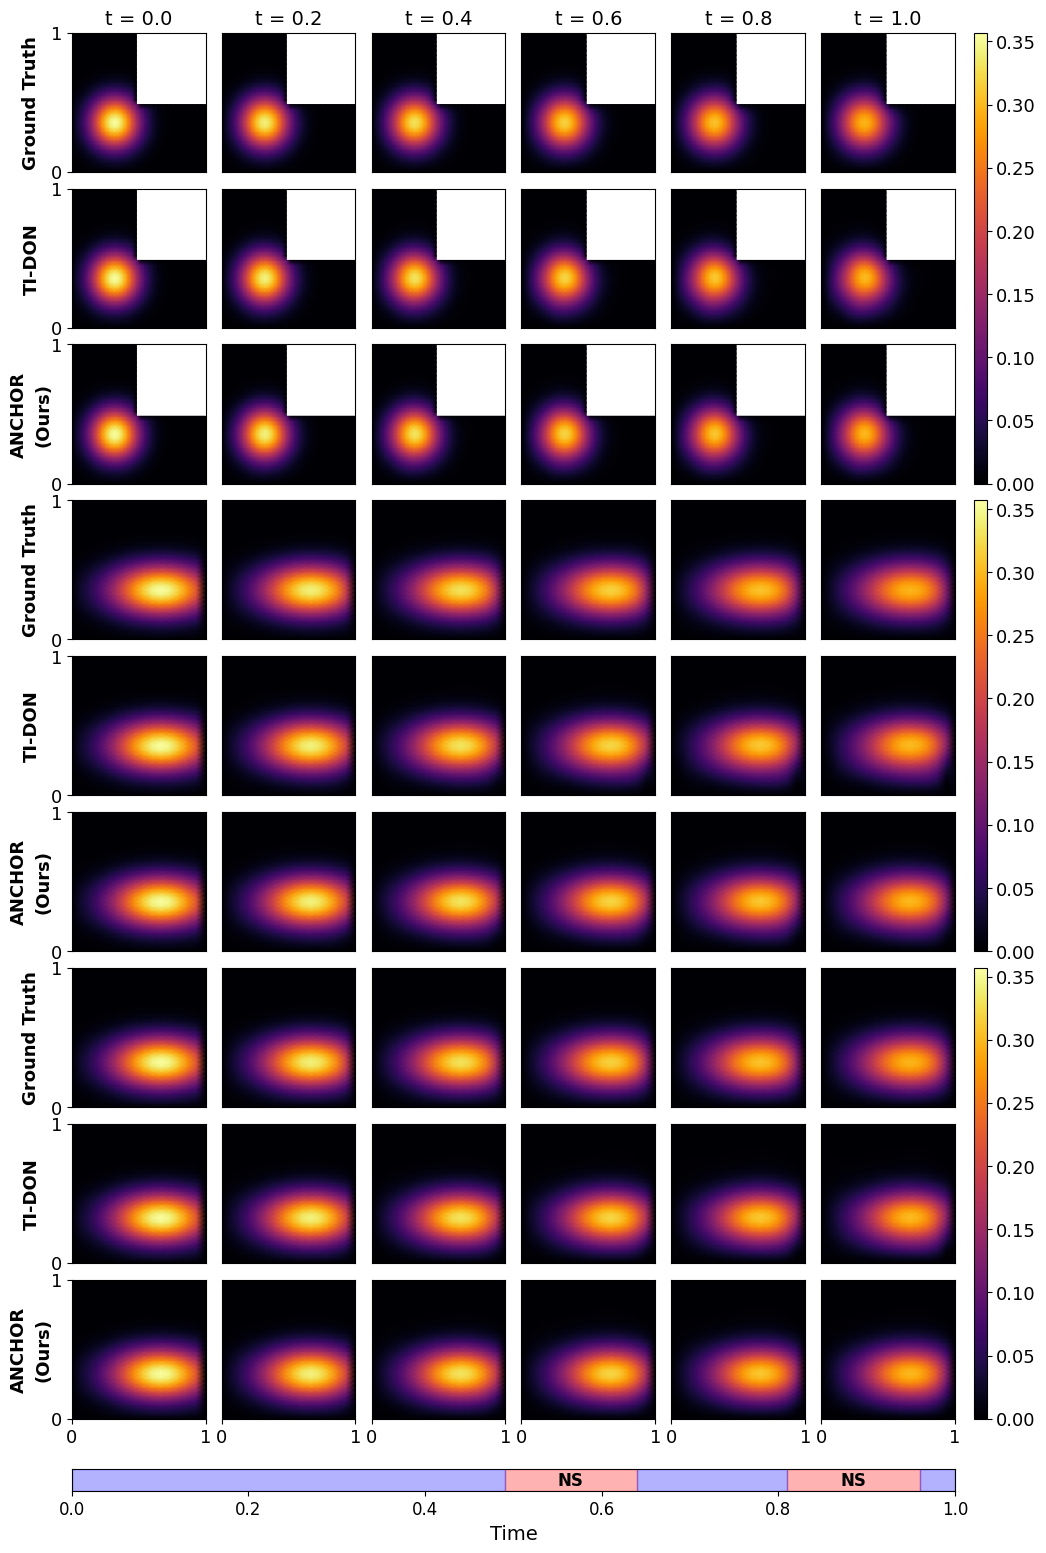

In [ ]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# GRID
x = np.linspace(0, 1, nx)
y = np.linspace(0, 1, ny)
z = np.linspace(0, 1, nz)

tsteps = [0, 20, 40, 60, 80, 100]
nrow = 3
ncol = len(tsteps)

row_labels = [
    "Ground Truth",
    # "Autoregressive",
    "TI-DON",
    "ANCHOR\n(Ours)",
]

# SLICE LOCATIONS
x_max = jnp.argmax(jnp.max(np.array(u_test[0]), axis=(0,2,3)))
y_max = jnp.argmax(jnp.max(np.array(u_test[0]), axis=(0,1,3)))
z_max = jnp.argmax(jnp.max(np.array(u_test[0]), axis=(0,1,2)))
print(x_max/32,y_max/32,z_max/32)

row_clims = (min(u_test[0][t].min() for t in tsteps),
                max(u_test[0][t].max() for t in tsteps))

# FIGURE

total_rows = 3 * nrow  # 3 planes
fig = plt.figure(figsize=(12, 18))

# Create GridSpec
gs = gridspec.GridSpec(total_rows, ncol, hspace=0.12, wspace=0.12)

top_row_axes = []

def plot_plane(plane_id, xlabel, ylabel):
    cb_axes = []          # axes for i = 1 and 2 (this plane only)
    cb_mappable = None
    for i in range(nrow):
        row_axes = []
        im = None

        for j in range(ncol):
  
            # SELECT GRID CELL
            row_idx = plane_id * nrow + i
            ax = fig.add_subplot(gs[row_idx, j])

            vmin, vmax = row_clims

            # SELECT SLICE
            if plane_id == 0:          # XY
                gt = u_test[0][tsteps[j]][:,:,z_max]
                mask = domain[:,:,z_max]
                xx, yy = x, y

            elif plane_id == 1:        # YZ
                gt = u_test[0][tsteps[j]][:,y_max,:]
                mask = domain[:,y_max,:]
                xx, yy = z, x

            else:                      # ZX
                gt = u_test[0][tsteps[j]][x_max,:,:]
                mask = domain[x_max,:,:]
                xx, yy = z, y

            # DATA PER ROW
            if i == 0:
                data = gt
            elif i == 1:
                if plane_id == 0:
                    data = (u_pred_model[tsteps[j]][:,:,z_max])
                elif plane_id == 1:
                    data = (u_pred_model[tsteps[j]][:,y_max,:])
                else:
                    data = (u_pred_model[tsteps[j]][x_max,:,:])
            elif i == 2:
                if plane_id == 0:
                    data = (u_pred_coup[tsteps[j]][:,:,z_max])
                elif plane_id == 1:
                    data = (u_pred_coup[tsteps[j]][:,y_max,:])
                else:
                    data = (u_pred_coup[tsteps[j]][x_max,:,:])

            # MASK + PLOT
            data = np.ma.array(data, mask=~mask)

            im = ax.pcolormesh(
                xx, yy, data,
                cmap='inferno', #if i == 0 else 'inferno'
                shading='gouraud',
                vmin=vmin, vmax=vmax
            )
            # ax.set_aspect('equal')

            # TICKS
            # X-ticks only for last row
            if i == nrow - 1 and plane_id == 2:
                ax.tick_params(labelbottom=True)
                top_row_axes.append(ax)
                # ax.set_xlabel(xlabel, fontsize=12)
                
            else:
                ax.tick_params(bottom=False, labelbottom=False)

            # Y-ticks only for first column
            if j == 0:
                ax.tick_params(labelleft=True)
                # ax.set_ylabel(ylabel, fontsize=12)
                # Row label
                ax.text(
                    -0.3, 0.5, f"{row_labels[i]}",
                    transform=ax.transAxes,
                    rotation=90,
                    va='center', ha='center',
                    fontsize=13, fontweight='bold',
                    linespacing=1.5   # ← controls spacing between lines
                )
            else:
                ax.tick_params(left=False, labelleft=False)

            # Column titles (first row only)
            if i == 0 and plane_id == 0:
                ax.set_title(f"t = {0.01 * tsteps[j]}", fontsize=14)

            ax.tick_params(labelsize=13)
            ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
            ax.yaxis.set_major_locator(mticker.MultipleLocator(1))
               
            row_axes.append(ax)

        cb_axes.extend(row_axes)

        if cb_mappable is None:
            cb_mappable = im

    # SHARED ERROR COLORBAR FOR THIS PLANE (i = 1 & 2)
    cbar = fig.colorbar(
        cb_mappable,
        ax=cb_axes,
        location='right',
        pad=0.02,
        fraction=0.03,   # ↓↓↓ narrower bar
        aspect=35
        )

    cbar.ax.tick_params(labelsize=13)
    # cbar_err.set_label("Absolute Error", fontsize=13)

# PLOT ALL PLANES
plot_plane(0, "X", "Y")   # XY
plot_plane(1, "Z", "X")   # YZ
plot_plane(2, "Z", "Y")   # ZX

# NUMBER LINE 
ax_left = top_row_axes[0]
ax_right = top_row_axes[-1]

pos_left = ax_left.get_position()
pos_right = ax_right.get_position()
# print(pos_left,pos_right)
ax_num = fig.add_axes([
    pos_left.x0,
    pos_left.y0 - 0.04,
    pos_right.x1 - pos_left.x0,
    0.012
])

ax_num.set_xlim(0, 1)
ax_num.set_ylim(0, 1)
ax_num.set_yticks([])

for s, e in zip(ts1, ts2):
    ax_num.axvspan(s, e, color='red', alpha=0.3)
    ax_num.text((s + e)/2, 0.5, "NS",
                ha='center', va='center', fontsize=12, fontweight='bold')

grey_intervals = []

# Before first red section
if ts1[0] > 0:
    grey_intervals.append((0, ts1[0]))

# Between red sections
for i in range(len(ts1) - 1):
    if ts2[i] < ts1[i + 1]:
        grey_intervals.append((ts2[i], ts1[i + 1]))

# After last red section
if ts2[-1] < 1:
    grey_intervals.append((ts2[-1], 1))

# Draw grey spans
for start, end in grey_intervals:
    ax_num.axvspan(start, end, color='blue', alpha=0.3)
    ax_num.set_xlabel("Time", fontsize=14)
ax_num.tick_params(labelsize=12)

plt.savefig(folder + sample_folder + "/solutions.pdf",
            dpi=300, bbox_inches="tight")
plt.show()